# Test rápido — DQN en LunarLander-v3
Entrena **300 episodios** (~10-15 s en CPU) con una red pequeña (32×32) para verificar que el agente aprende y ver la curva en tiempo real.

> Este notebook es solo de verificación. El entrenamiento completo (5 000 ep.) está en `DeepQLearning_experiment.ipynb`.

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

from agents import DQNAgent
from plotting import plot, plot_losses

SEED = 2024
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Imports OK')

Imports OK


In [2]:
env = gym.make('LunarLander-v3')
env.reset(seed=SEED)
print(f'Estados: {env.observation_space.shape[0]}   Acciones: {env.action_space.n}')

Estados: 8   Acciones: 4


## Agente de prueba
Red pequeña **32×32** y buffer de 5 000 para que entrene rápido. Los hiperparámetros definitivos están en el notebook principal.

In [3]:
agent = DQNAgent(
    env,
    epsilon=1.0,
    alpha=0.001,
    discount_factor=0.99,
    decay=True,
    buffer_capacity=5000,
    batch_size=64,
    target_update_freq=100,
    hidden_size=32,
    num_hidden_layers=2,
    use_cpu=True
)

agent.train(num_episodes=600)

Entrenando en: cpu


 10%|█         | 62/600 [00:02<00:20, 25.71it/s]

success: -133.9956, epsilon: 0.7403, loss: 7.6066


 20%|██        | 123/600 [00:05<00:22, 20.99it/s]

success: -107.8747, epsilon: 0.5480, loss: 207.8983


...

success: -66.0234, epsilon: 0.0902, loss: 2.5773


 90%|█████████ | 541/600 [01:18<00:09,  6.18it/s]

success: -62.9316, epsilon: 0.0668, loss: 5.7448


100%|██████████| 600/600 [01:25<00:00,  7.01it/s]

success: -62.5839, epsilon: 0.0494, loss: 3.1131


## Resultados

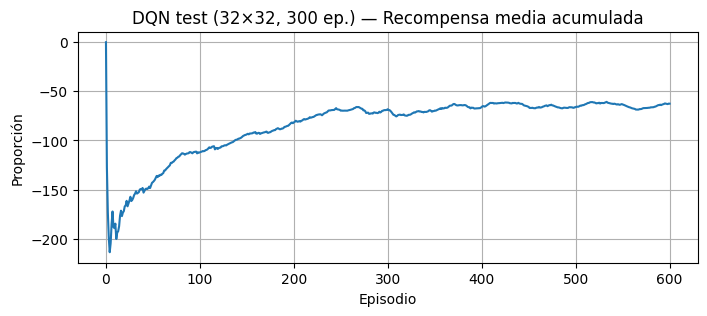

Recompensa media final:   -62.58
Epsilon final:            0.0494
Pasos de entrenamiento:   209851
Pérdidas registradas:     209851


In [4]:
list_stats, list_lengths, list_losses = agent.stats()

plot(list_stats, title='DQN test (32×32, 300 ep.) — Recompensa media acumulada')
print(f'Recompensa media final:   {list_stats[-1]:.2f}')
print(f'Epsilon final:            {agent.epsilon:.4f}')
print(f'Pasos de entrenamiento:   {agent._step_count}')
print(f'Pérdidas registradas:     {len(list_losses)}')

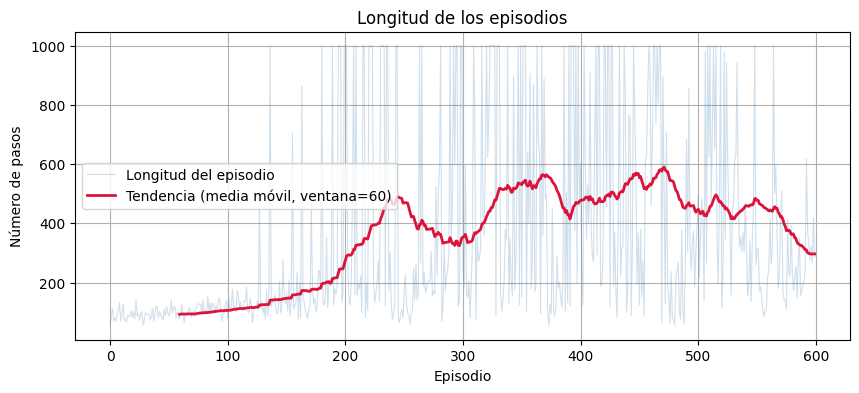

Longitud media (últimos 50 ep.): 282.4 pasos


In [5]:
from plotting import plot_lengths
plot_lengths(list_lengths)
print(f'Longitud media (últimos 50 ep.): {np.mean(list_lengths[-50:]):.1f} pasos')

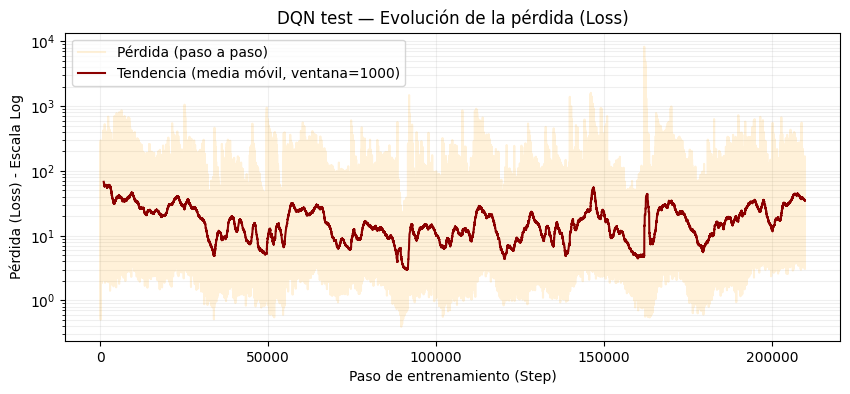

Loss final: 3.1131


In [6]:
plot_losses(list_losses, title='DQN test — Evolución de la pérdida (Loss)')
print(f'Loss final: {list_losses[-1]:.4f}')

## Episodio greedy
Ejecuta un episodio con $\epsilon=0$ (solo explotación) para ver qué ha aprendido el agente en solo 300 episodios.

> Con tan pocos episodios el cohete aún no aterriza bien, pero debería mostrar intentos de control básico.

In [7]:
from plotting import show_greedy_episode_qnet, frames_to_gif

env_demo = gym.make('LunarLander-v3', render_mode='rgb_array')
env_demo.reset(seed=SEED)

# Reutilizamos los pesos ya entrenados (epsilon=0 → solo greedy)
agent.epsilon = 0.0
agent.env = env_demo

frames = show_greedy_episode_qnet(env_demo, agent, max_steps=500)
env_demo.close()

gif_path = frames_to_gif(frames, filename='test_dqn.gif')
print(f'GIF guardado: {gif_path}  ({len(frames)} frames)')

GIF guardado: test_dqn.gif  (280 frames)


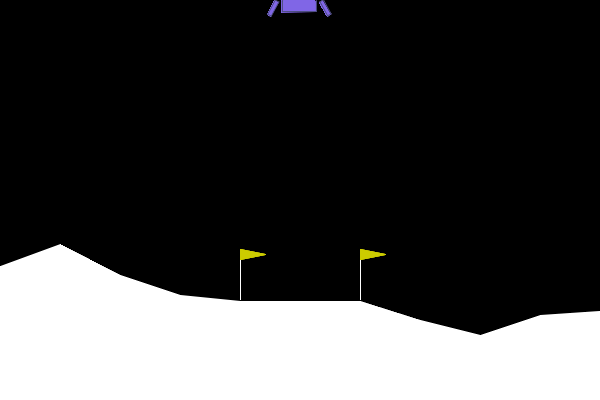

In [8]:
from IPython.display import Image
Image('test_dqn.gif')